# Guided DDIM Reconstruction – `train_large_ladiff` model

Test the diffusion model trained with `train_large_ladiff.py` on pre-computed
`la_fbp` / `gt_fbp` volumes saved by the **Large_LA_Dataset** notebook.

**Pipeline:**
1. Load `la_fbp.npy` / `gt_fbp.npy` and the percentile norm sidecar JSON.
2. Load the matching projections from disk (same setup as Large_LA_Dataset).
3. Load the trained UNet checkpoint.
4. For each test slice: run Guided DDIM with per-slice sinogram consistency.
5. Compute PSNR and SSIM vs. ground truth.


## 1. Imports & Setup

In [1]:
import sys, importlib, json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path('/myhome/sdate')
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

# ── Data loading ──────────────────────────────────────────────────────────
from inct.dataset_slices import ProjectionSliceDataset

from ladiff.fourier_wedge import (
    build_missing_wedge_mask,
    apply_missing_wedge,
    inpaint_fourier_wedge,
    apply_circle_mask
)

# ── Diffusion model / pipeline ────────────────────────────────────────────
from diffusers.models import UNet2DModel
from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline

# ── Metrics ───────────────────────────────────────────────────────────────
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

import lovely_tensors as lt
lt.monkey_patch()

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")

import torch


def fft_2D(x, s=None, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    if ortho:
        fft_image = torch.fft.fftn(x, s=s, norm='ortho', dim=dim)
    else:
        fft_image = torch.fft.fftn(x, s=s, dim=dim)
    return torch.fft.fftshift(fft_image, dim=dim)


def ifft_2D(x, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    f_space = torch.fft.ifftshift(x, dim=dim)
    # Perform inverse 2D Fourier Transform
    if ortho:
        return torch.fft.ifftn(f_space, norm='ortho', dim=dim)
    else:
        return torch.fft.ifftn(f_space, dim=dim)


zarr not installed


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda  |  PyTorch 2.8.0+cu128
GPU: NVIDIA A100 80GB PCIe


## 2. Configuration

These parameters must match the **Large_LA_Dataset** notebook used to produce the saved volumes.

In [2]:
# ── Must match Large_LA_Dataset notebook ──────────────────────────────────
FILE_IDX         = 1
DATA_PATH        = Path(f'/myhome/data/sdate/shared/compression_paper/small/file_{FILE_IDX}_extracted')
ANGULAR_RANGE_FRAC = 0.6   # fraction of projections used as la (must match notebook)

GAMMA_CORRECTION_DEG = 0.0

# ── Saved volume paths (output of Large_LA_Dataset) ───────────────────────
RECON_PATH = Path(f'/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction')
GT_FBP_PATH  = RECON_PATH / f'gt_fbp_{FILE_IDX}.npy'
NORM_JSON    = RECON_PATH / f'la_fourier_{FILE_IDX}_norm.json'

In [3]:
# ── Inference ─────────────────────────────────────────────────────────────
NUM_INFERENCE_STEPS = 50

# ── Test slices: indices into the la_fbp volume (0 .. num_slices-1) ───────
# Set to None to test every TEST_STRIDE-th slice across the whole volume.
TEST_SLICE_INDICES = None   # e.g. [50, 100, 150] or None for automatic
TEST_STRIDE        = 20     # used when TEST_SLICE_INDICES is None
N_SAMPLES      = 6      # how many dataset items to visualise
SEED           = 0
DET_SPACING_MM   = 1.0
LAMINO_ANGLE_DEG = 0.0

## 3. Load Saved Volumes and Normalization

In [4]:
gt_fbp_np = np.load(GT_FBP_PATH)  # (num_slices, H, W)
gt_fbp = torch.tensor(gt_fbp_np)   # (num_slices, H, W)
print(f"gt_fbp shape : {gt_fbp.shape}  [{gt_fbp.min():.4f}, {gt_fbp.max():.4f}]")

metric_min = float(np.percentile(gt_fbp_np, 1))
metric_max = float(np.percentile(gt_fbp_np, 99))

# ── Normalization from sidecar JSON ───────────────────────────────────────
with open(NORM_JSON) as f:
    norm_cfg = json.load(f)

norm_min = float(norm_cfg['norm_min'])
norm_max = float(norm_cfg['norm_max'])
print(f"\nNorm (p1–p99): min={norm_min:.4f}, max={norm_max:.4f}")

# Normalization functions: raw ↔ [0, 1]
def normalize_fn(x):
    return apply_circle_mask((x - norm_min) / (norm_max - norm_min))

def denormalize_fn(x):
    return apply_circle_mask(x * (norm_max - norm_min) + norm_min)

NUM_SLICES, SLICE_H, SLICE_W = gt_fbp.shape
print(f"\nVolume: {NUM_SLICES} slices of {SLICE_H}×{SLICE_W}")


gt_fbp shape : torch.Size([540, 640, 640])  [-0.0590, 0.0787]

Norm (p1–p99): min=-0.0011, max=0.0031

Volume: 540 slices of 640×640


tensor[10, 640, 640] n=4096000 (16Mb) x∈[-0.004, 0.008] μ=0.001 σ=0.001

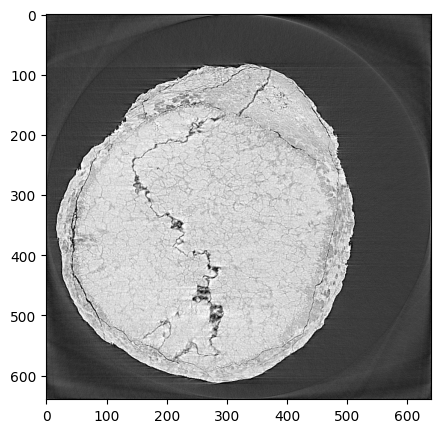

In [5]:
IDX = 9
plt.imshow(gt_fbp[IDX], vmin=metric_min, vmax=metric_max)

# NUM_SLICES = 2
# gt_fbp = gt_fbp[:NUM_SLICES]

NUM_SLICES = 10
gt_fbp = gt_fbp[IDX].unsqueeze(0).repeat(NUM_SLICES, 1, 1)

gt_fbp


## 4. Compute LA Fourier reconstruction

In [6]:
# ── Parameters ────────────────────────────────────────────────────────────────
ANGULAR_RANGE_DEG = int(ANGULAR_RANGE_FRAC * 180)   # 108 for ANGULAR_RANGE_FRAC=0.6
START_ANGLE       = (180 - ANGULAR_RANGE_DEG) // 2  # degrees; tilt starts here, runs to START_ANGLE + ANGULAR_RANGE_DEG
TILT_AXIS         = 0      # axis the sample rotates around: 0=kz  1=ky  2=kx

la_fbp = apply_missing_wedge(gt_fbp.to(device), ANGULAR_RANGE_DEG, START_ANGLE, TILT_AXIS).cpu()
la_fbp

la_fbp = apply_circle_mask(la_fbp)
gt_fbp = apply_circle_mask(gt_fbp)

## 5. Visualise a Sample Slice

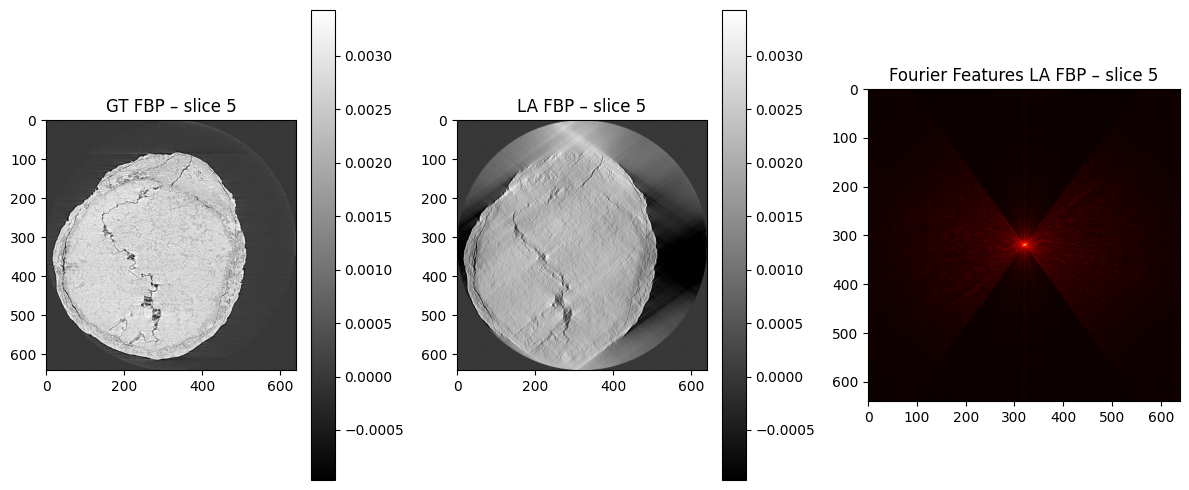

GT  range: [-0.0036, 0.0078]
LA  range: [-0.0038, 0.0057]
Norm [0,1] range covers p1=-0.0010 – p99=0.0034


In [7]:
PREVIEW_IDX = NUM_SLICES // 2

# PREVIEW_IDX = 0

gt_slice  = gt_fbp[PREVIEW_IDX]
la_slice  = la_fbp[PREVIEW_IDX]

vmin, vmax = metric_min, metric_max

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(gt_slice, cmap='gray', vmin=metric_min, vmax=metric_max)
axes[0].set_title(f'GT FBP – slice {PREVIEW_IDX}')
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(la_slice, cmap='gray', vmin=metric_min, vmax=metric_max)
axes[1].set_title(f'LA FBP – slice {PREVIEW_IDX}')
plt.colorbar(axes[1].images[0], ax=axes[1])

axes[2].imshow(torch.log1p(torch.abs(fft_2D(la_slice))), cmap='hot')
axes[2].set_title(f'Fourier Features LA FBP – slice {PREVIEW_IDX}')


plt.tight_layout()
plt.show()

print(f"GT  range: [{gt_slice.min():.4f}, {gt_slice.max():.4f}]")
print(f"LA  range: [{la_slice.min():.4f}, {la_slice.max():.4f}]")
print(f"Norm [0,1] range covers p1={metric_min:.4f} – p99={metric_max:.4f}")


## 6. Load Trained Diffusion Model

In [8]:
CHECKPOINT_PATH = project_root / 'checkpoints' / f'ddpm_ladiff_cond_ladiff_f{FILE_IDX}.pt'
CHECKPOINT_PATH

Path('/myhome/sdate/checkpoints/ddpm_ladiff_cond_ladiff_f1.pt')

In [9]:
channels = (64, 64, 128, 128, 256, 256)
model = UNet2DModel(
    sample_size=SLICE_W,   # slices are (SLICE_H, SLICE_W); model expects square → use W
    in_channels=2,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=channels,
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D",
        "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D",
        "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
    class_embed_type="timestep"
).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"  Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"  in/out channels: 1 / 1  (single 2-D slice)")


Model loaded from /myhome/sdate/checkpoints/ddpm_ladiff_cond_ladiff_f1.pt
  Parameters : 28,527,937
  in/out channels: 1 / 1  (single 2-D slice)


(tensor[640, 640] n=409600 (1.6Mb) x∈[-4.580, 5.057] μ=0.020 σ=0.998 cuda:0,
 tensor[640, 640] n=409600 (1.6Mb) x∈[-0.004, 0.008] μ=0.001 σ=0.001)

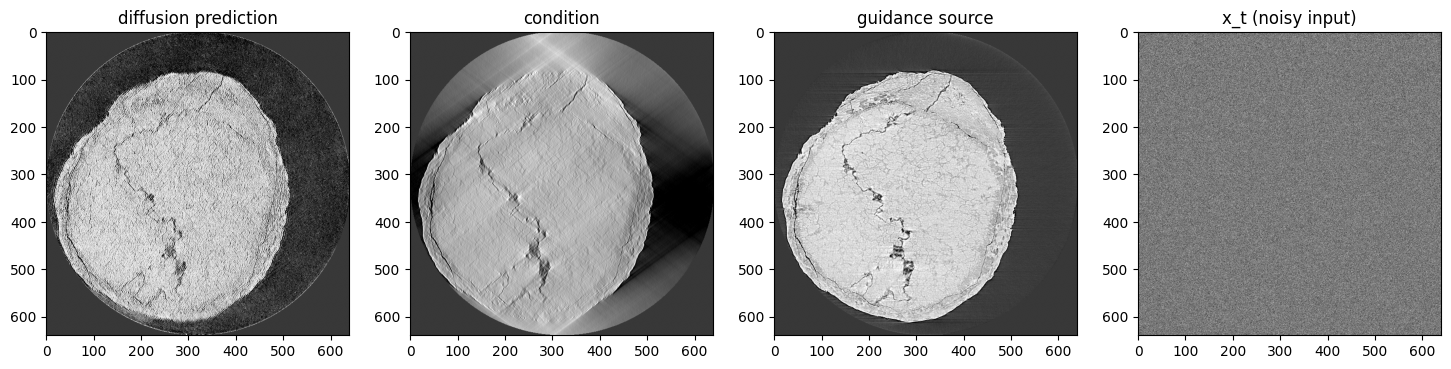

In [28]:

scheduler = GuidedDDIMScheduler(1000)
scheduler.set_timesteps(NUM_INFERENCE_STEPS)
timestep = 800
x = normalize_fn(gt_slice)
conditioning = normalize_fn(la_slice)
x_t = scheduler.add_noise(x, torch.randn_like(la_slice), timesteps=torch.tensor([timestep])).to(device)
with torch.no_grad():
    conditional = torch.LongTensor([1.]).to(device)
    model_input = torch.stack([x_t, conditional * conditioning.to(device)], dim=0).to(device)  # (2, H, W)
    

    noise_pred = model(model_input.unsqueeze(0), timestep = torch.tensor([timestep]).to(device), class_labels=conditional, return_dict=False)[0].squeeze()  # (H, W)
    x_0_pred = scheduler.step(noise_pred, timestep=timestep, sample=x_t)['pred_original_sample']  # (H, W)
    
    diffusion_pred = denormalize_fn(x_0_pred)
    # diffusion_pred = inpaint_guidance(
    #     source_volume=gt_slice.unsqueeze(0).to(device),              # oracle: original full-angle tensor on device
    #     vol_init=diffusion_pred.unsqueeze(0).to(device)
    # )

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes[0].imshow(diffusion_pred.squeeze().cpu(), cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('diffusion prediction')
axes[1].imshow(la_slice, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('condition')
axes[2].imshow(gt_slice, cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title('guidance source')
axes[3].imshow(x_t.squeeze().cpu(), cmap='gray')
axes[3].set_title('x_t (noisy input)')
x_t, gt_slice

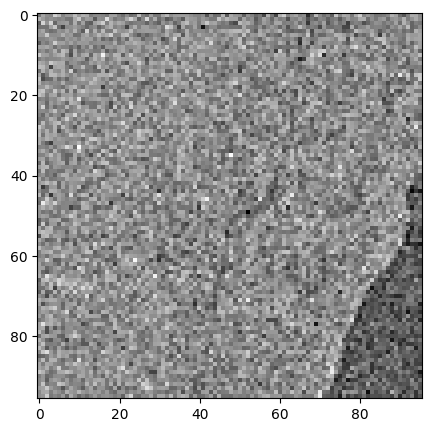

In [27]:
plt.imshow(x_t.squeeze().cpu()[400:496, 400:496], cmap='gray')  # --- IGNORE ---

## 7. Guidance Function

At each DDIM step the scheduler calls `guidance_fn(x_0_raw, t)` where `x_0_raw` is the predicted clean image in **raw** (un-normalised) space with shape `(1, 1, H, W)`.  We run a few GD iterations of `gd_reconstruction_masked` using the limited-angle projections for the current slice to enforce data consistency, then return the updated estimate in the same shape.

In [11]:
from ladiff.recon_utils import inpaint_guidance as _inpaint_guidance

def inpaint_guidance(
    source_volume: torch.Tensor,
    vol_init: torch.Tensor,
    timestep: int = 0,
    inpaint_steps: int = 1,
) -> torch.Tensor:
    """Thin wrapper that passes notebook-local geometry params to recon_utils."""
    with torch.no_grad():
        x = _inpaint_guidance(
            source_volume=source_volume,
            vol_init=vol_init,
            angular_range_deg=ANGULAR_RANGE_DEG,
            start_angle=START_ANGLE,
            tilt_axis=TILT_AXIS,
            device=device,
            timestep=timestep,
            inpaint_steps=inpaint_steps,
        )
        x = torch.mean(x, dim=0).repeat(x.shape[0], 1, 1)  # average over slices to get a single slice (for testing)
    return x


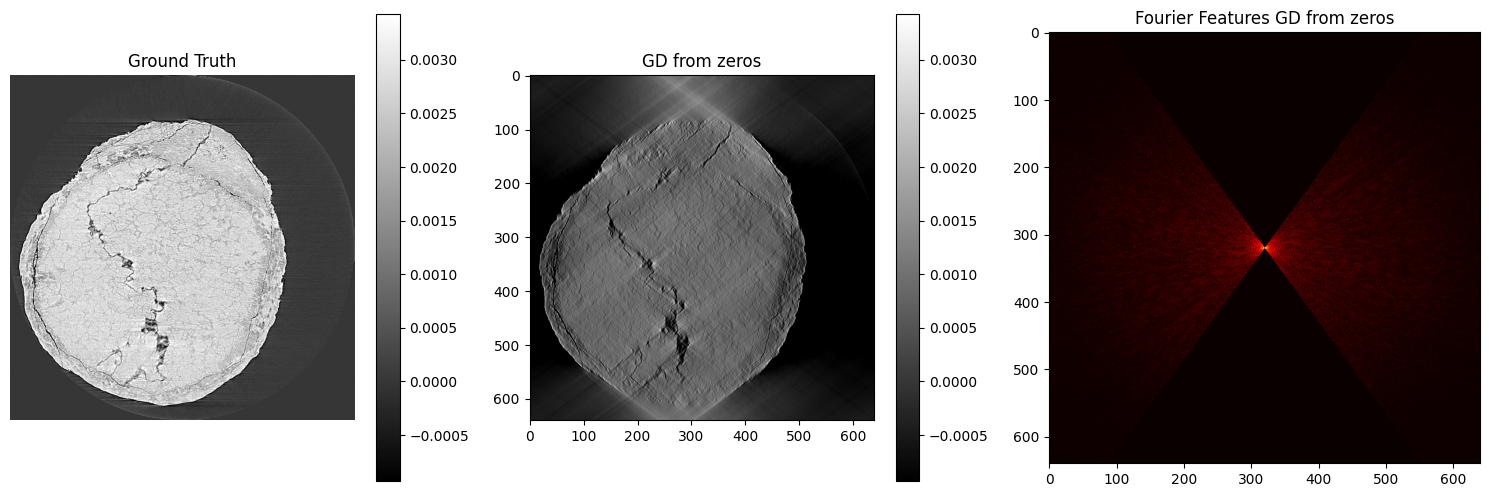

In [12]:
TEST_SLICE_IDX = NUM_SLICES // 2 
# Quick test: guidance from zero initialisation (uses SW projections since t=999 > threshold)
recons_gd = inpaint_guidance(
    source_volume=gt_fbp.to(device),              # oracle: original full-angle tensor on device
    vol_init=0*la_fbp.to(device),
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_fbp[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
axes[0].set_title('Ground Truth')
axes[0].axis('off')
plt.colorbar(axes[0].images[0], ax=axes[0])
axes[1].imshow(recons_gd[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
plt.colorbar(axes[1].images[0], ax=axes[1])
axes[1].set_title(f'GD from zeros')
axes[2].imshow(torch.log1p(torch.abs(fft_2D(recons_gd[TEST_SLICE_IDX]).cpu())), cmap='hot')
axes[2].set_title(f'Fourier Features GD from zeros')
plt.tight_layout()
plt.show()

In [13]:
guidance = lambda x, t: inpaint_guidance(
    source_volume=gt_fbp.to(device),              # oracle: original full-angle tensor on device
    vol_init=x.to(device),
    timestep=int(t),
    inpaint_steps=5
)

# guidance = lambda x, t: x

## 8. Run Guided DDIM on a Single Test Slice

Quick sanity check before the full sweep.

In [14]:
diffusion_recon = la_fbp.clone().to(device)
# diffusion_recon = 0*gt_fbp.clone().to(device)
# diffusion_recon = iterative_recon.clone().to(device)

In [15]:
torch.cuda.empty_cache()
NUM_INFERENCE_STEPS = 40

noise_scheduler = GuidedDDIMScheduler(
    num_train_timesteps=1000,
    guidance_function=guidance,
)

pipeline = DDIMPipeline(
    unet=model.to(device),
    scheduler=noise_scheduler,
    fdk_prior=diffusion_recon.to(device),
    normalize_fn=normalize_fn,
    denormalize_fn=denormalize_fn,
    slice_batch_size=32,
)

result = pipeline.truncated_pipeline(
    initial_guess=diffusion_recon.to(device),                   # start from the guided reconstruction (can also start from zeros or FBP)
    start_step=int(0.05 * NUM_INFERENCE_STEPS),
    num_inference_steps=NUM_INFERENCE_STEPS,
    use_clipped_model_output=True,
    p_use_conditioning=1.0
)
diffusion_recon = result.images  # (H, W)
diffusion_recon = apply_circle_mask(inpaint_guidance(
    source_volume=gt_fbp.to(device),              # oracle: original full-angle tensor on device
    vol_init=diffusion_recon.to(device),
))

print(f"Guided DDIM reconstruction done")
print(f"  shape: {diffusion_recon.shape}")
print(f"  range: [{diffusion_recon.min():.4f}, {diffusion_recon.max():.4f}]")

  0%|          | 0/38 [00:00<?, ?it/s]

100%|██████████| 38/38 [00:12<00:00,  2.97it/s]

Guided DDIM reconstruction done
  shape: torch.Size([10, 640, 640])
  range: [-0.0038, 0.0047]


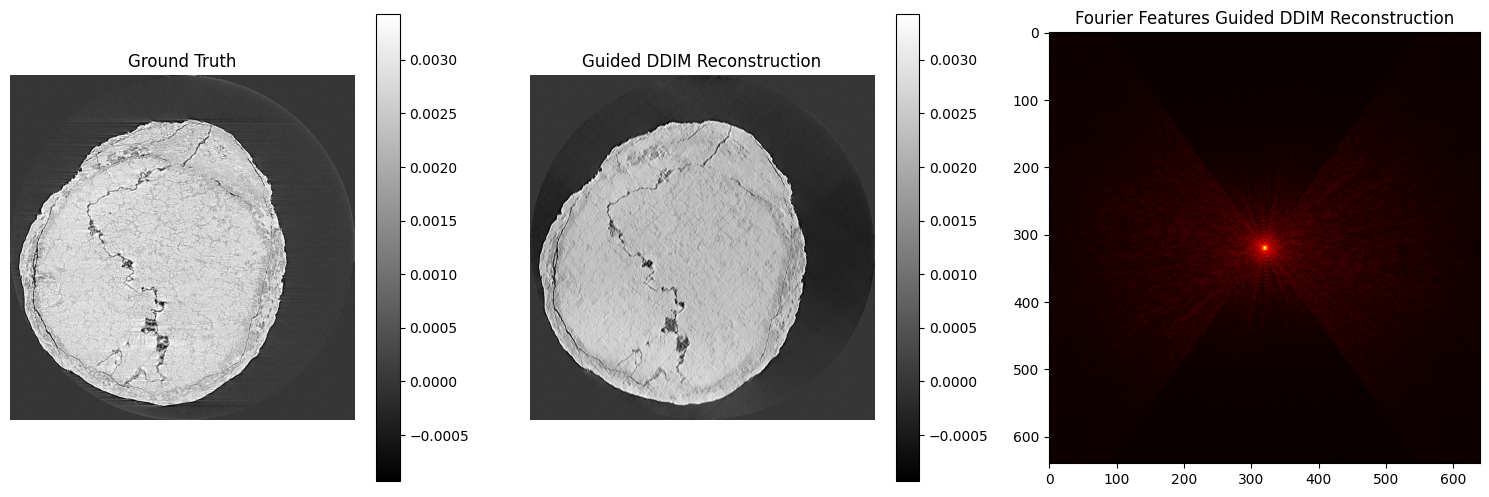

In [16]:
# plot diffusion_recon[0] and gt_slice side to side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_slice.cpu().numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
axes[0].set_title('Ground Truth')
axes[0].axis('off')
plt.colorbar(axes[0].images[0], ax=axes[0])
axes[1].imshow(diffusion_recon[0].cpu().numpy(), cmap='gray', vmin=metric_min, vmax=metric_max)
axes[1].set_title('Guided DDIM Reconstruction')
axes[1].axis('off')
plt.colorbar(axes[1].images[0], ax=axes[1])
axes[2].imshow(torch.log1p(torch.abs(fft_2D(diffusion_recon[0].cpu()))), cmap='hot')
axes[2].set_title('Fourier Features Guided DDIM Reconstruction')
plt.tight_layout()
plt.show()

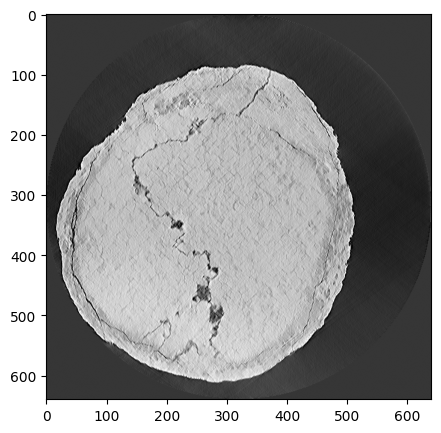

In [17]:
diffusion_recon = diffusion_recon.mean(dim=0).repeat(NUM_SLICES, 1, 1)

diffusion_recon = apply_circle_mask(inpaint_guidance(
    source_volume=gt_fbp.to(device),              # oracle: original full-angle tensor on device
    vol_init=diffusion_recon.to(device),
))

plt.imshow(apply_circle_mask(diffusion_recon[:]).mean(dim=0).cpu().detach(), cmap='gray', vmin=metric_min, vmax=metric_max)

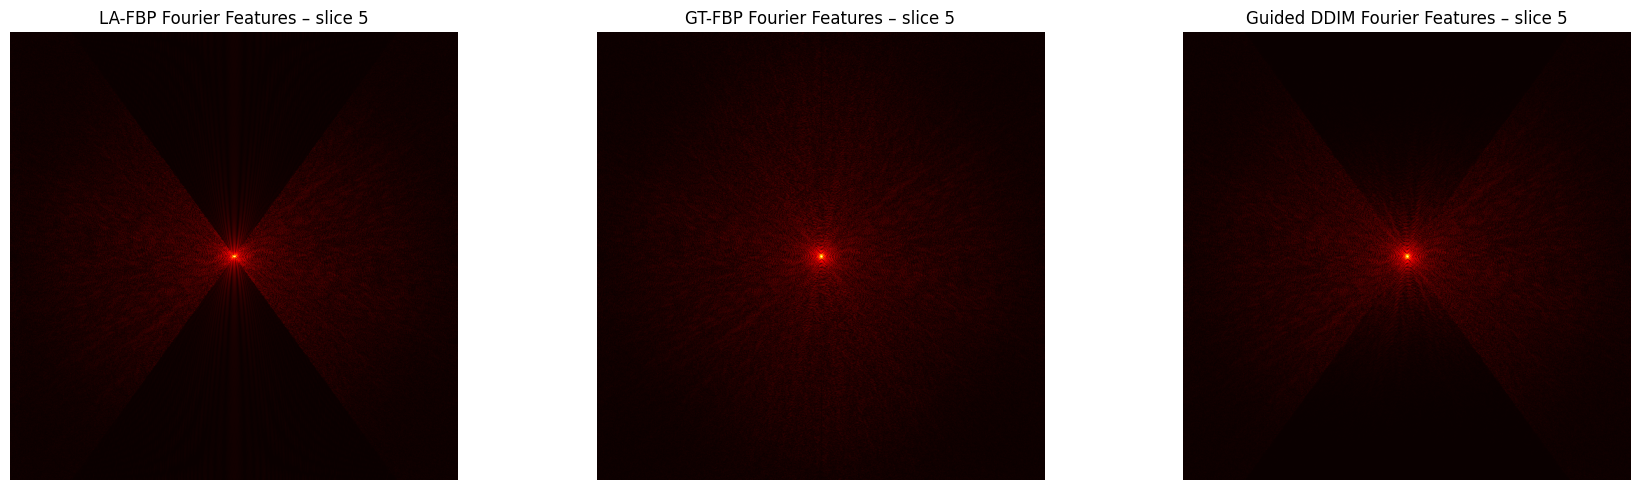

In [18]:
fft_idx = PREVIEW_IDX if 'PREVIEW_IDX' in globals() else 0

fft_inputs = {
    'LA-FBP': la_fbp[fft_idx],
    'GT-FBP': gt_fbp[fft_idx],
    'Guided DDIM': diffusion_recon[fft_idx],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, image) in zip(axes, fft_inputs.items()):
    fft_recon = fft_2D(image)
    magnitude = torch.log1p(torch.abs(fft_recon))
    ax.imshow(magnitude.cpu().detach(), cmap='hot')
    ax.set_title(f'{title} Fourier Features – slice {fft_idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Multi-Slice Evaluation

Sweep over selected slices, compute per-slice PSNR / SSIM, and report aggregate statistics.

In [19]:
from tqdm import tqdm
TEST_SLICE_INDICES = None
# Determine which slices to evaluate
if TEST_SLICE_INDICES is not None:
    eval_slices = list(TEST_SLICE_INDICES)
else:
    eval_slices = list(range(0, NUM_SLICES))
eval_slices = [0]

print(f"Evaluating {len(eval_slices)} slices: {eval_slices[:5]}{'...' if len(eval_slices) > 5 else ''}")

results = []
for k in tqdm(eval_slices, desc='DDIM inference'):
    ddim_recon = diffusion_recon[k].cpu().numpy()  # (H, W)
    gt_k  = gt_fbp[k].numpy()
    la_k  = la_fbp[k].numpy()
    dr    = metric_max - metric_min

    psnr_d = compute_psnr(gt_k, ddim_recon, data_range=dr)
    ssim_d = compute_ssim(gt_k, ddim_recon, data_range=dr)
    psnr_l = compute_psnr(gt_k, la_k,       data_range=dr)
    ssim_l = compute_ssim(gt_k, la_k,       data_range=dr)

    results.append({
        'slice':     k,
        'psnr_ddim': psnr_d,
        'ssim_ddim': ssim_d,
        'psnr_la':   psnr_l,
        'ssim_la':   ssim_l,
        'ddim_recon': ddim_recon,
        'la_fbp': la_k,
    })
    torch.cuda.empty_cache()

print("\nDone.")


Evaluating 1 slices: [0]


DDIM inference: 100%|██████████| 1/1 [00:00<00:00, 18.19it/s]


Done.


## 10. Metrics Summary

 Slice   DDIM PSNR  DDIM SSIM   LA-FBP PSNR  LA-FBP SSIM
------------------------------------------------------------
     0       21.76     0.4992         15.10       0.5473
------------------------------------------------------------
  Mean       21.76     0.4992         15.10       0.5473
   Std        0.00     0.0000          0.00       0.0000


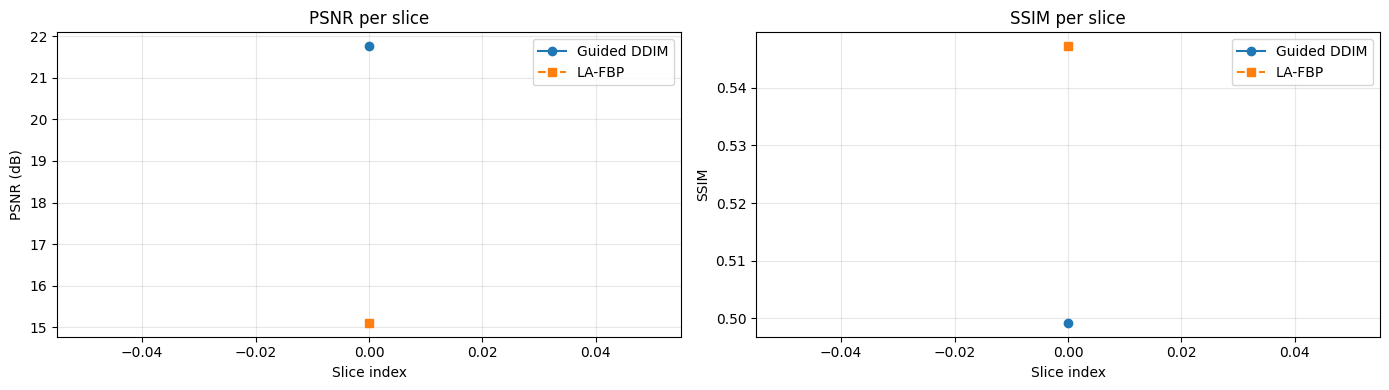

In [20]:
psnr_ddim_all = [r['psnr_ddim'] for r in results]
ssim_ddim_all = [r['ssim_ddim'] for r in results]
psnr_la_all   = [r['psnr_la']   for r in results]
ssim_la_all   = [r['ssim_la']   for r in results]
slices_all    = [r['slice']      for r in results]

# ── Per-slice table ───────────────────────────────────────────────────────
print(f"{'Slice':>6}  {'DDIM PSNR':>10} {'DDIM SSIM':>10}  {'LA-FBP PSNR':>12} {'LA-FBP SSIM':>12}")
print("-" * 60)
for r in results:
    print(f"{r['slice']:>6d}  {r['psnr_ddim']:>10.2f} {r['ssim_ddim']:>10.4f}  "
          f"{r['psnr_la']:>12.2f} {r['ssim_la']:>12.4f}")
print("-" * 60)
print(f"{'Mean':>6}  {np.mean(psnr_ddim_all):>10.2f} {np.mean(ssim_ddim_all):>10.4f}  "
      f"{np.mean(psnr_la_all):>12.2f} {np.mean(ssim_la_all):>12.4f}")
print(f"{'Std':>6}  {np.std(psnr_ddim_all):>10.2f} {np.std(ssim_ddim_all):>10.4f}  "
      f"{np.std(psnr_la_all):>12.2f} {np.std(ssim_la_all):>12.4f}")

# ── PSNR / SSIM over slices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(slices_all, psnr_ddim_all, 'o-', label='Guided DDIM')
axes[0].plot(slices_all, psnr_la_all,   's--', label='LA-FBP')
axes[0].set_xlabel('Slice index')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR per slice')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(slices_all, ssim_ddim_all, 'o-', label='Guided DDIM')
axes[1].plot(slices_all, ssim_la_all,   's--', label='LA-FBP')
axes[1].set_xlabel('Slice index')
axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM per slice')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Visual Comparison Gallery

In [21]:
# optimizer = torch.optim.AdamW(
#     model.parameters()
# )
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
# }, CHECKPOINT_PATH)

In [ ]:
# Show GT | DDIM | LA-FBP | error maps for up to 4 evenly-spaced results
show_results = results[::max(1, len(results) // 4)][:4]
ncols = len(show_results)

fig, axes = plt.subplots(5, ncols, figsize=(5 * ncols, 20))
if ncols == 1:
    axes = axes.reshape(-1, 1)

for col, r in enumerate(show_results):
    k   = r['slice']
    gt  = gt_fbp[k]
    la  = la_fbp[k]
    ddim = r['ddim_recon']
    la_k = r['la_fbp']
    vmin, vmax = np.percentile(gt, [1, 99])

    axes[0, col].imshow(gt,   cmap='gray', vmin=metric_min, vmax=metric_max)
    axes[0, col].set_title(f'GT – slice {k}');    axes[0, col].axis('off')

    axes[1, col].imshow(ddim, cmap='gray', vmin=metric_min, vmax=metric_max)
    axes[1, col].set_title(f'Guided DDIM\nPSNR={r["psnr_ddim"]:.2f} dB  SSIM={r["ssim_ddim"]:.4f}')
    axes[1, col].axis('off')

    axes[2, col].imshow(la,   cmap='gray', vmin=metric_min, vmax=metric_max)
    axes[2, col].set_title(f'LA-FBP\nPSNR={r["psnr_la"]:.2f} dB  SSIM={r["ssim_la"]:.4f}')
    axes[2, col].axis('off')

    err   = gt - ddim
    emax  = max(abs(err.min()), abs(err.max()))
    axes[3, col].imshow(err, cmap='RdBu', vmin=-emax, vmax=emax)
    axes[3, col].set_title(f'Error (GT − DDIM)');  axes[3, col].axis('off')

    err   = gt - la_k
    emax  = max(abs(err.min()), abs(err.max()))
    axes[4, col].imshow(err, cmap='RdBu', vmin=-emax, vmax=emax)
    axes[4, col].set_title(f'Error (GT − LA-FBP)');  axes[4, col].axis('off')

plt.suptitle('Guided DDIM vs LA-FBP — qualitative comparison', fontsize=14)
plt.tight_layout()
plt.show()


: 

# Saving Results

In [23]:
import os
import json

PATH = f"/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction"
# make sure the directory exists
os.makedirs(PATH, exist_ok=True)

diffusion_np = diffusion_recon.cpu().numpy()

np.save(PATH + f"/diffusion_{FILE_IDX}_1_round.npy", diffusion_np)

## 12. Iterative Refinement Loop

Re-run the guided DDIM pipeline 5 outer iterations.  
Within each outer iteration we sweep `start_step` from 0.1 → 0.9 (5 values), so each iteration applies progressively coarser denoising passes on top of the current estimate.  
PSNR / SSIM on the middle slice are tracked at every inner step.

In [24]:
guidance = lambda x, t: inpaint_guidance(
    source_volume=gt_fbp.to(device),              # oracle: original full-angle tensor on device
    vol_init=x.to(device),
    timestep=int(t),
    inpaint_steps=1
)

# guidance = lambda x, t: x

In [ ]:
from tqdm.auto import tqdm

NUM_INFERENCE_STEPS_ITER = 10
# START_STEP_FRACS = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7] + 4 * [0.8]  # fractions of the total steps where we start the next iteration
START_STEP_FRACS = [0.8]
NUM_OUTER_ITERS  = 40

# ── Reset reconstruction to LA-FBP baseline ───────────────────────────────
# iterative_recon = la_fbp.clone().to(device)
iterative_recon = diffusion_recon.clone().to(device)

iter_metrics   = []   # {outer_iter, start_step_frac, psnr_full, ssim_full, psnr_mean, ssim_mean}
iter_snapshots = {}   # (outer_iter, start_step_frac) → {'full': np, 'mean': np}

mid       = NUM_SLICES // 2
gt_mid_np = gt_fbp[mid].numpy()
dr_mid    = metric_max - metric_min

for outer_iter in range(NUM_OUTER_ITERS):
    print(f"\n── Outer iteration {outer_iter + 1}/{NUM_OUTER_ITERS} ──────────────────────────")
    for i, start_step_frac in enumerate(START_STEP_FRACS):
        torch.cuda.empty_cache()

        # Recreate scheduler so its internal state is clean
        _sched = GuidedDDIMScheduler(
            num_train_timesteps=1000,
            guidance_function=guidance,
        )
        _pipe = DDIMPipeline(
            unet=model.to(device),
            scheduler=_sched,
            fdk_prior=la_fbp.clone().to(device),
            normalize_fn=normalize_fn,
            denormalize_fn=denormalize_fn,
            slice_batch_size=32,
        )

        result = _pipe.truncated_pipeline(
            initial_guess=iterative_recon.to(device),
            start_step=int(start_step_frac * NUM_INFERENCE_STEPS_ITER),
            num_inference_steps=NUM_INFERENCE_STEPS_ITER,
            use_clipped_model_output=True,
        )
        iterative_recon = result.images
    

        # iterative_recon = apply_circle_mask(inpaint_guidance(
        #     source_volume=gt_fbp.to(device),
        #     vol_init=iterative_recon.to(device),
        # ))

        # ── Mean reconstruction: average across the batch of slices ──────
        # (all slices are treated as a batch; the mean collapses noise variance)
        mean_recon = iterative_recon.mean(dim=0).repeat(NUM_SLICES, 1, 1)

        mean_recon = apply_circle_mask(inpaint_guidance(
            source_volume=gt_fbp.to(device),
            vol_init=mean_recon.to(device),
        ))

        # ── Metrics: middle slice, before and after mean ──────────────────
        full_mid_np = iterative_recon[mid].cpu().numpy()
        mean_mid_np = mean_recon[mid].cpu().numpy()

        psnr_full = compute_psnr(gt_mid_np, full_mid_np, data_range=dr_mid)
        ssim_full = compute_ssim(gt_mid_np, full_mid_np, data_range=dr_mid)
        psnr_mean = compute_psnr(gt_mid_np, mean_mid_np, data_range=dr_mid)
        ssim_mean = compute_ssim(gt_mid_np, mean_mid_np, data_range=dr_mid)

        iter_metrics.append({
            'outer_iter':      outer_iter,
            'start_step_frac': start_step_frac,
            'psnr_full':       psnr_full,
            'ssim_full':       ssim_full,
            'psnr_mean':       psnr_mean,
            'ssim_mean':       ssim_mean,
        })
        iter_snapshots[(outer_iter, start_step_frac)] = {
            'full': full_mid_np.copy(),
            'mean': mean_mid_np.copy(),
        }

        print(f"  start_step={start_step_frac:.2f}  "
              f"PSNR full={psnr_full:.2f} dB  SSIM full={ssim_full:.4f}  |  "
              f"PSNR mean={psnr_mean:.2f} dB  SSIM mean={ssim_mean:.4f}")

        # ── Next initial guess is the mean reconstruction ─────────────────
        iterative_recon = mean_recon.to(device)

print("\nIterative refinement done ✓")

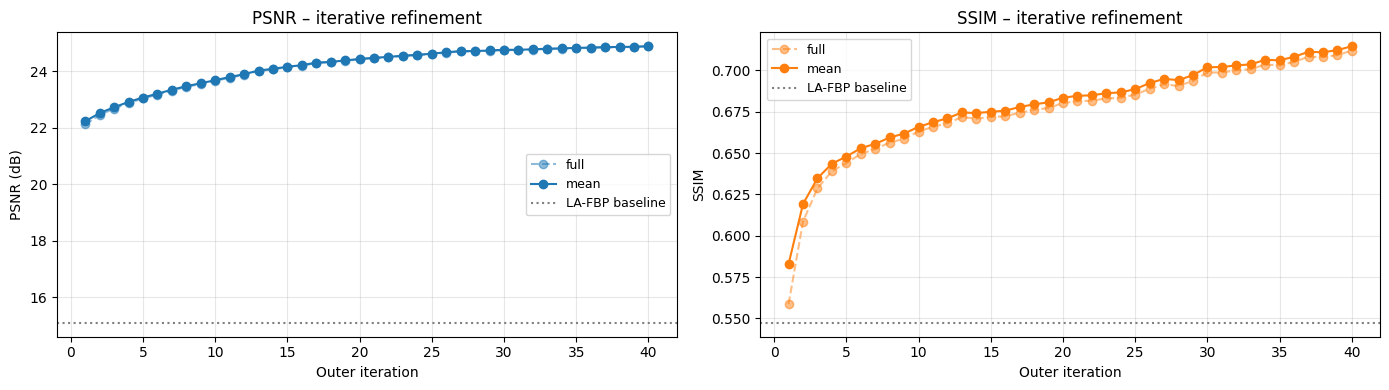

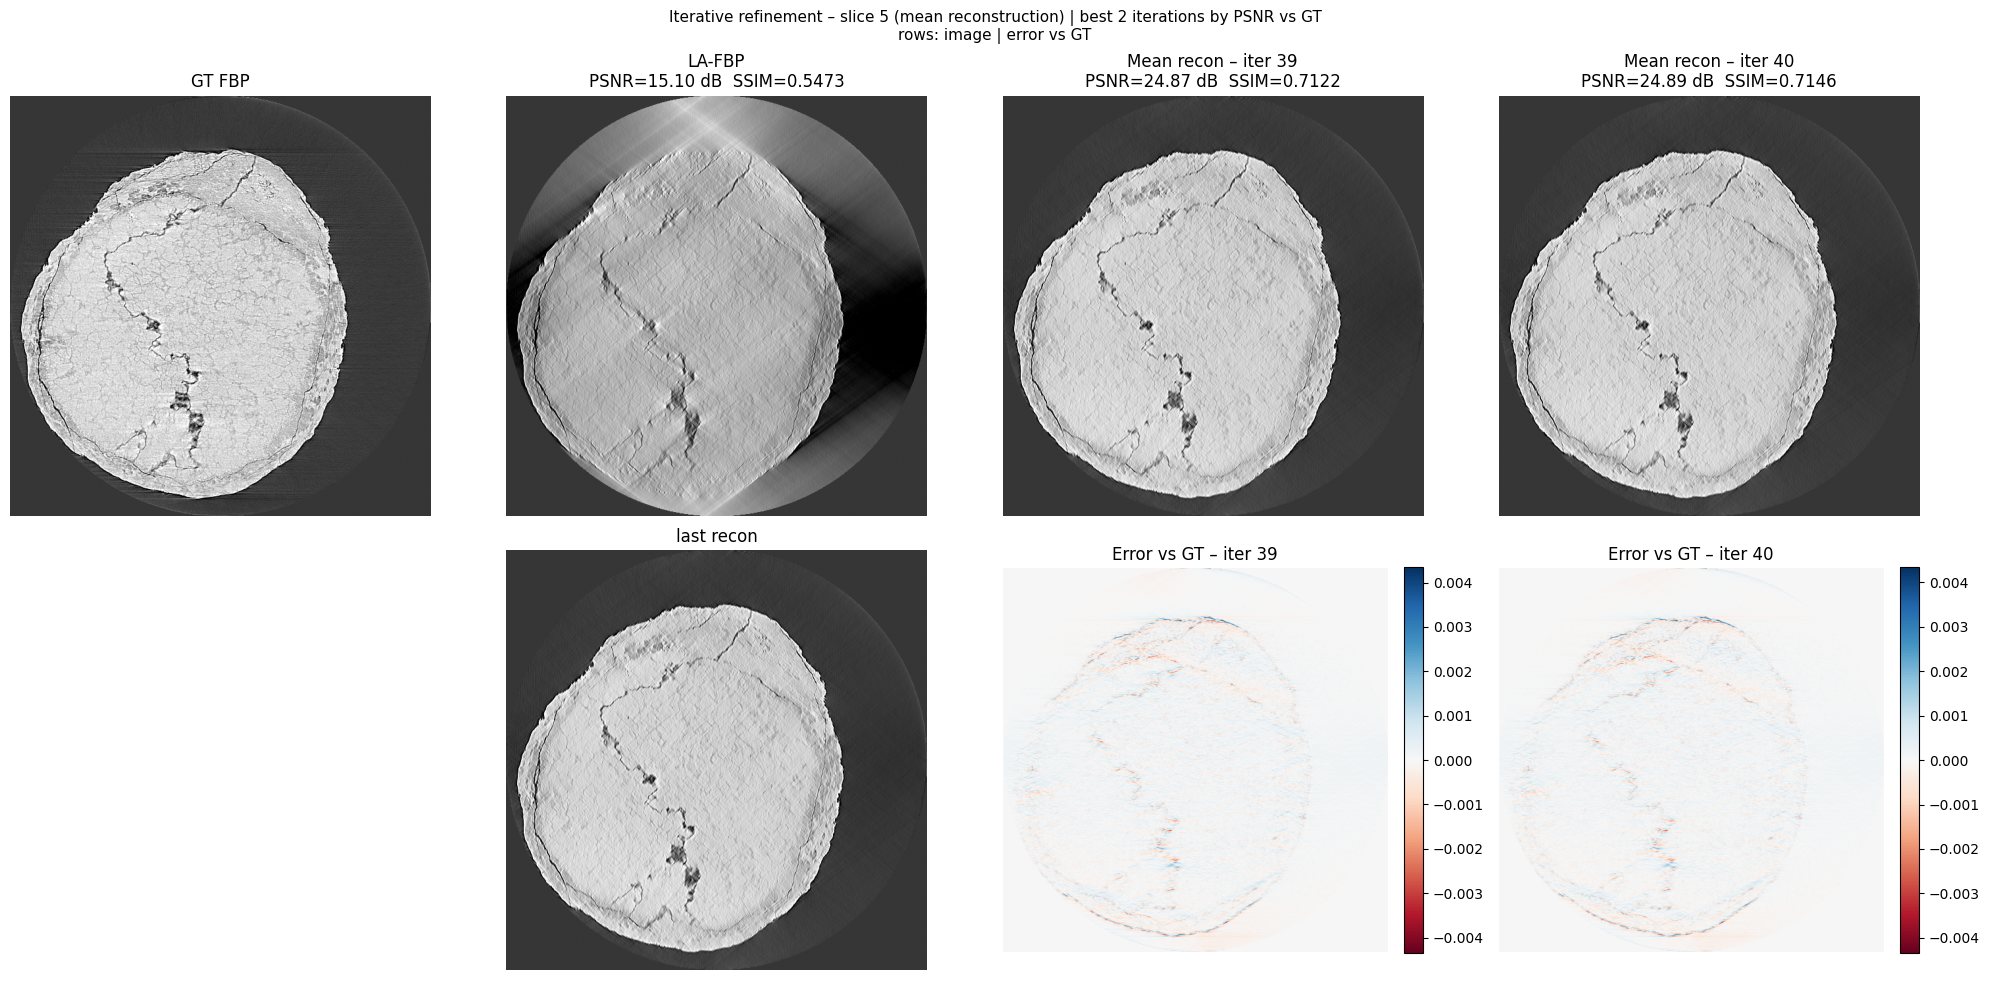

: 

In [ ]:
psnr_la_base = compute_psnr(gt_mid_np, la_fbp[mid].numpy(), data_range=dr_mid)
ssim_la_base = compute_ssim(gt_mid_np, la_fbp[mid].numpy(), data_range=dr_mid)

# ── Metric curves: full-slice and mean vs outer iteration ─────────────────
iters_x   = [x['outer_iter'] + 1 for x in iter_metrics]
psnr_full = [x['psnr_full']      for x in iter_metrics]
psnr_mean = [x['psnr_mean']      for x in iter_metrics]
ssim_full = [x['ssim_full']      for x in iter_metrics]
ssim_mean = [x['ssim_mean']      for x in iter_metrics]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(iters_x, psnr_full, 'o--', color='C0', alpha=0.5, label='full')
axes[0].plot(iters_x, psnr_mean, 'o-',  color='C0',             label='mean')
axes[0].axhline(psnr_la_base, color='gray', ls=':', lw=1.5, label='LA-FBP baseline')
axes[0].set_xlabel('Outer iteration')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR – iterative refinement')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters_x, ssim_full, 'o--', color='C1', alpha=0.5, label='full')
axes[1].plot(iters_x, ssim_mean, 'o-',  color='C1',             label='mean')
axes[1].axhline(ssim_la_base, color='gray', ls=':', lw=1.5, label='LA-FBP baseline')
axes[1].set_xlabel('Outer iteration')
axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM – iterative refinement')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Qualitative gallery – best 2 iterations vs GT ─────────────────────────
# Pick the two outer iterations with highest mean-recon PSNR vs GT
sorted_by_psnr = sorted(iter_metrics, key=lambda x: x['psnr_mean'], reverse=True)
best_iters = [sorted_by_psnr[0]['outer_iter'], sorted_by_psnr[min(len(sorted_by_psnr)-1, 1)]['outer_iter']]
best_iters_sorted = sorted(best_iters)  # display in chronological order

vmin_i, vmax_i = metric_min, metric_max

# Columns: GT | LA-FBP | best_iter_1 | best_iter_2
ncols = 4
fig, axes = plt.subplots(2, ncols, figsize=(5 * ncols, 10))

# Row 0 – images
axes[0, 0].imshow(gt_mid_np,           cmap='gray', vmin=vmin_i, vmax=vmax_i)
axes[0, 0].set_title('GT FBP');        axes[0, 0].axis('off')
axes[0, 1].imshow(la_fbp[mid].numpy(), cmap='gray', vmin=vmin_i, vmax=vmax_i)
axes[0, 1].set_title(f'LA-FBP\nPSNR={psnr_la_base:.2f} dB  SSIM={ssim_la_base:.4f}')
axes[0, 1].axis('off')

# Row 1 – errors vs GT (only for recon columns; blank for GT and LA-FBP)
axes[1, 0].axis('off')
axes[1, 1].axis('off')
# Row 0 – images
axes[1, 1].imshow(iterative_recon[0].cpu().numpy(),           cmap='gray', vmin=vmin_i, vmax=vmax_i)
axes[1, 1].set_title('last recon');        axes[1, 1].axis('off')


for col, oi in enumerate(best_iters_sorted, start=2):
    snap       = iter_snapshots[(oi, START_STEP_FRACS[-1])]
    mean_recon = snap['mean']
    psnr_m = compute_psnr(gt_mid_np, mean_recon, data_range=dr_mid)
    ssim_m = compute_ssim(gt_mid_np, mean_recon, data_range=dr_mid)

    axes[0, col].imshow(mean_recon, cmap='gray', vmin=vmin_i, vmax=vmax_i)
    axes[0, col].set_title(f'Mean recon – iter {oi+1}\nPSNR={psnr_m:.2f} dB  SSIM={ssim_m:.4f}')
    axes[0, col].axis('off')

    err  = gt_mid_np - mean_recon
    emax = max(abs(err.min()), abs(err.max()))
    im = axes[1, col].imshow(err, cmap='RdBu', vmin=-emax, vmax=emax)
    axes[1, col].set_title(f'Error vs GT – iter {oi+1}')
    axes[1, col].axis('off')
    plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)

plt.suptitle(
    f'Iterative refinement – slice {mid} (mean reconstruction) | best 2 iterations by PSNR vs GT\n'
    f'rows: image | error vs GT',
    fontsize=11,
)
plt.tight_layout()
plt.show()